In [42]:
import pandas as pd

In [43]:
url = "https://github.com/kitlapp/Telco_ML/raw/main/ml_ready_dataset.parquet"
df = pd.read_parquet(url, engine="pyarrow")
df.head()

,Is_Churned,Total_Charges,Avg_Monthly_Charge,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Is_PaperlessBilling,...,Has_StreamingMovies_NoInternet,Has_MultipleLines_No,Has_MultipleLines_NoPhone,Is_InternetService_FiberOptic,Is_InternetService_None,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
0,False,29.85,29.85,1,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,False
1,False,1889.50,55.57,34,True,False,False,False,True,False,...,False,True,False,False,False,True,False,False,False,True
2,True,108.15,54.08,2,True,False,False,False,True,True,...,False,True,False,False,False,False,False,False,False,True
3,False,1840.75,40.91,45,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
4,True,151.65,75.82,2,False,False,False,False,True,True,...,False,True,False,True,False,False,False,False,True,False


In [44]:
#exploring how preprocessing went + my dataset
print(df.shape)

(7043, 31)


In [45]:
print(df.dtypes)

Is_Churned                             bool
Total_Charges                       float64
Avg_Monthly_Charge                  float64
Tenure                                int64
Is_Male                                bool
Is_Senior                              bool
Is_Married                             bool
Has_Dependents                         bool
Has_PhoneService                       bool
Is_PaperlessBilling                    bool
Has_OnlineSecurity_No                  bool
Has_OnlineSecurity_NoInternet          bool
Has_OnlineBackup_No                    bool
Has_OnlineBackup_NoInternet            bool
Has_DeviceProtection_No                bool
Has_DeviceProtection_NoInternet        bool
Has_TechSupport_No                     bool
Has_TechSupport_NoInternet             bool
Has_StreamingTV_No                     bool
Has_StreamingTV_NoInternet             bool
Has_StreamingMovies_No                 bool
Has_StreamingMovies_NoInternet         bool
Has_MultipleLines_No            

In [46]:
print(df.isnull().sum())

Is_Churned                          0
Total_Charges                       0
Avg_Monthly_Charge                  0
Tenure                              0
Is_Male                             0
Is_Senior                           0
Is_Married                          0
Has_Dependents                      0
Has_PhoneService                    0
Is_PaperlessBilling                 0
Has_OnlineSecurity_No               0
Has_OnlineSecurity_NoInternet       0
Has_OnlineBackup_No                 0
Has_OnlineBackup_NoInternet         0
Has_DeviceProtection_No             0
Has_DeviceProtection_NoInternet     0
Has_TechSupport_No                  0
Has_TechSupport_NoInternet          0
Has_StreamingTV_No                  0
Has_StreamingTV_NoInternet          0
Has_StreamingMovies_No              0
Has_StreamingMovies_NoInternet      0
Has_MultipleLines_No                0
Has_MultipleLines_NoPhone           0
Is_InternetService_FiberOptic       0
Is_InternetService_None             0
Is_Contract_

In [47]:
df.describe()

,Total_Charges,Avg_Monthly_Charge,Tenure
count,7043.000000,7043.000000,7043.000000
mean,2279.734304,64.698184,32.371149
std,2266.794470,30.270690,24.559481
min,0.000000,0.000000,0.000000
25%,398.550000,35.650000,9.000000
50%,1394.550000,70.300000,29.000000
75%,3786.600000,90.170000,55.000000
max,8684.800000,121.400000,72.000000


In [48]:
!pip install shap --quiet

import numpy as np            # numerical operations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns         # prettier plots
import shap                   # explainability
import warnings
warnings.filterwarnings('ignore')

# Model selection & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV

# Classification metrics
from sklearn.metrics import (
    accuracy_score,        # overall % correct
    f1_score,              # balance between precision & recall
    classification_report, # full breakdown per class
    ConfusionMatrixDisplay # visual confusion matrix
)

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,   # average prediction error in $ units
    r2_score               # how much variance the model explains (0–1)
)

# Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor  # pre-installed in Colab

RANDOM_STATE = 42
print("All my libraries are set up for WORK!")

All my libraries are set up for WORK!


Let's get into preparing my dataset for Regression and Classification.

# **Step 1:** I would need to drop 1 column (Total_Charges).
Total_Charges is basically Tenure × Avg_Monthly_Charge, it is a mathematical combination of other columns already in the dataset.
Therefire, for regression (predicting **Avg_Monthly_Charge**): keeping it would be cheating (lol) the model would just reverse-calculate the answer instead of actually learning.
For classification (predicting **churn**): it adds no new information that Tenure and Avg_Monthly_Charge don't already give separately.
So it either causes data leakage or redundancy,so hurts the quality of my model.

In [49]:
df = df.drop(columns=['Total_Charges'])

print(df.shape)
print(df['Is_Churned'].value_counts())
df.head()

(7043, 30)
Is_Churned
False    5174
True     1869
Name: count, dtype: int64


,Is_Churned,Avg_Monthly_Charge,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Is_PaperlessBilling,Has_OnlineSecurity_No,...,Has_StreamingMovies_NoInternet,Has_MultipleLines_No,Has_MultipleLines_NoPhone,Is_InternetService_FiberOptic,Is_InternetService_None,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
0,False,29.85,1,False,False,True,False,False,True,True,...,False,False,True,False,False,False,False,False,True,False
1,False,55.57,34,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
2,True,54.08,2,True,False,False,False,True,True,False,...,False,True,False,False,False,False,False,False,False,True
3,False,40.91,45,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
4,True,75.82,2,False,False,False,False,True,True,True,...,False,True,False,True,False,False,False,False,True,False


In [50]:
print("Class distribution:")
print(df['Is_Churned'].value_counts())
print(f"\nNot Churned: {5174/7043*100:.1f}%")
print(f"Churned:     {1869/7043*100:.1f}%")

Class distribution:
Is_Churned
False    5174
True     1869
Name: count, dtype: int64

Not Churned: 73.5%
Churned:     26.5%


# There is a ***mild class imbalance*** (73/27)
no resampling needed. I can handle this directly in XGBoost using scale_pos_weight=5174/1869 (spoiler: changed my mind later, and then again changed my mind haha)


# **Model 1: XGBoost**

In [51]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    scale_pos_weight=5174/1869,  # handles 73/27 imbalance
    random_state=RANDOM_STATE,
    eval_metric='logloss'        # measures how confident & correct predictions are
)

In [52]:
param_grid_xgb = {
    'n_estimators': [100, 200],   # how many trees to build
    'max_depth': [3, 5],          # how deep each tree can go
    'learning_rate': [0.05, 0.1]  # how much each tree corrects the previous one
}

In [53]:
#changed my mind for this

#!pip install imbalanced-learn --quiet
#from imblearn.over_sampling import SMOTE

#smote = SMOTE(random_state=RANDOM_STATE)

In [54]:
X_clf = df.drop(columns=['Is_Churned'])
y_clf = df['Is_Churned']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

#X_clf_train, y_clf_train = smote.fit_resample(X_clf_train, y_clf_train)
print(f"Train: {X_clf_train.shape} | Test: {X_clf_test.shape}")

#print("After SMOTE:", pd.Series(y_clf_train).value_counts().to_dict())

Train: (5634, 29) | Test: (1409, 29)


In [55]:
grid_xgb = GridSearchCV(
    xgb_clf,          # the model we defined
    param_grid_xgb,   # the combinations to try
    cv=5,             # split training data into 5 folds to test each combination
    scoring='f1',     # pick the best combination based on F1 score
    n_jobs=-1         # use all CPU cores to speed it up
)

grid_xgb.fit(X_clf_train, y_clf_train)

print("Best params:", grid_xgb.best_params_)
print("Best F1 score (train):", round(grid_xgb.best_score_, 4))

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best F1 score (train): 0.6315


My model found that


*  200 trees works better than 100


*  shallow trees (depth 3) — avoids overfitting


*   slow learning rate (0.05) — learns carefully and




With SMOTE it was
*  deeper trees (depth 5) — the model needs more complexity to learn the balanced data
*  faster learning rate (0.1) — with balanced classes it can learn more aggressively

In [56]:
best_xgb_clf = grid_xgb.best_estimator_

y_pred_xgb = best_xgb_clf.predict(X_clf_test)

print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_clf_test, y_pred_xgb):.4f}")
print("\n", classification_report(y_clf_test, y_pred_xgb))

Accuracy: 0.7488
F1 Score: 0.6289

               precision    recall  f1-score   support

       False       0.91      0.73      0.81      1035
        True       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



Despite SMOTE boosting training F1 from 0.63 to 0.83, test performance was slightly worse. Accuracy dropped from 0.7488 to 0.7395 and F1 dropped from 0.6289 to 0.6197. Recall on churners stayed identical at 0.80 either way. This is a classic sign of overfitting to synthetic data — the model learned the fake SMOTE rows well but didn't generalise better to real unseen data. Conclusion: scale_pos_weight alone was the better approach for this dataset. So I will go back and remove the SMOTE approach.

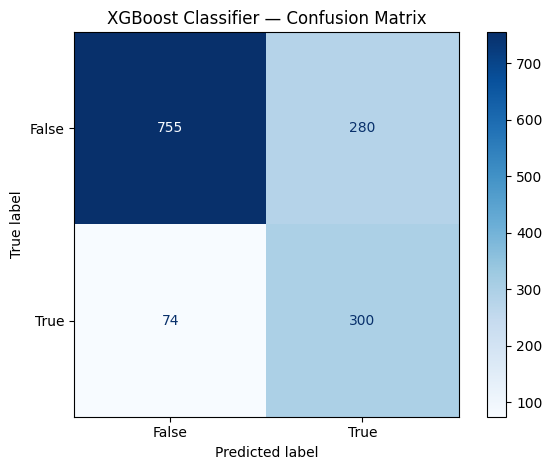

In [57]:
ConfusionMatrixDisplay.from_estimator(best_xgb_clf, X_clf_test, y_clf_test, cmap='Blues')
plt.title("XGBoost Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

*   Top left (755) — predicted Not Churned, actually Not Churned ✅ correct

*   Top right (280) — predicted Churned, actually Not Churned ❌ false alarm

*   Bottom left (74) — predicted Not Churned, actually Churned ❌ missed churners

*   Bottom right (300) — predicted Churned, actually Churned ✅ correct



In business terms:

The model correctly caught 300 out of 374 churners, that's the 0.80 recall we saw
It only missed 74 churners, these are the dangerous ones, customers who left without being flagged
The 280 false alarms are acceptable, worst case we offer a loyal customer a discount they didn't need lol.


# Model 2: Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',  # handles 73/27 imbalance
    random_state=RANDOM_STATE,
    max_iter=1000             # gives it enough iterations to converge
)

In [59]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],        # controls how strict the model is — lower = simpler
    'solver': ['lbfgs', 'liblinear'] # algorithm used to find the best boundary
}

In [60]:
grid_lr = GridSearchCV(
    log_reg,         # the model we defined
    param_grid_lr,   # the combinations to try
    cv=5,            # 5 fold cross validation
    scoring='f1',    # optimise for F1
    n_jobs=-1        # use all CPU cores
)

grid_lr.fit(X_clf_train, y_clf_train)

print("Best params:", grid_lr.best_params_)
print("Best F1 score (train):", round(grid_lr.best_score_, 4))

Best params: {'C': 0.1, 'solver': 'liblinear'}
Best F1 score (train): 0.6335


*   C=0.1 — a simpler, more regularised model to avoid overfitting
*   liblinear — works better for smaller/simpler problems like this



F1 of 0.6335 on training, very close to XGBoost's 0.6315, which is interesting! Let's see how it performs on the test set.

In [61]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_clf_test)

print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_lr):.4f}")
print(f"F1 Score: {f1_score(y_clf_test, y_pred_lr):.4f}")
print("\n", classification_report(y_clf_test, y_pred_lr))

Accuracy: 0.7431
F1 Score: 0.6173

               precision    recall  f1-score   support

       False       0.90      0.73      0.81      1035
        True       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



XGBoost wins on every metric but the gap is small. This tells us:

*   The problem is not super complex — even a simple straight line (Logistic Regression) gets close
*   XGBoost is still the better model — more trees = captures more complex patterns



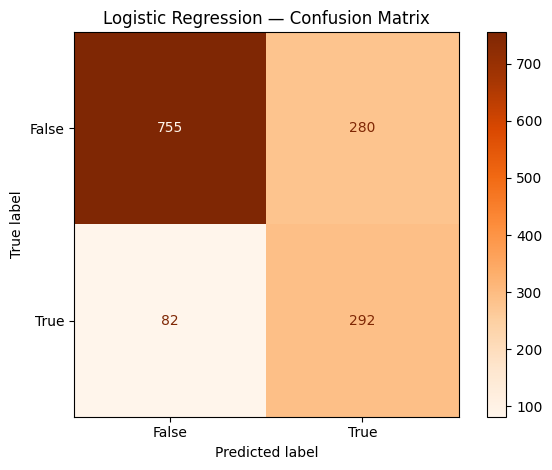

In [62]:
ConfusionMatrixDisplay.from_estimator(best_lr, X_clf_test, y_clf_test, cmap='Oranges')
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

*   Top left (755) — predicted Not Churned, actually Not Churned ✅ identical to XGBoost
*   Top right (280) — predicted Churned, actually Not Churned ❌ identical to XGBoost
*   Bottom left (82) — predicted Not Churned, actually Churned ❌ missed 82 churners
*   Bottom right (292) — predicted Churned, actually Churned ✅ caught 292 churners


vs XGBoost:
*   XGBoost caught 300 churners, Logistic Regression caught 292 — XGBoost is better
*   XGBoost missed 74 churners, Logistic Regression missed 82 — XGBoost is better
*   Non-churner predictions are exactly the same for both models

Now let's understand how much each feature pushed the prediction towards churned or not churned.

In [65]:
import shap
explainer = shap.Explainer(best_xgb_clf, X_clf_train.astype(float))
shap_values = explainer(X_clf_test.astype(float))

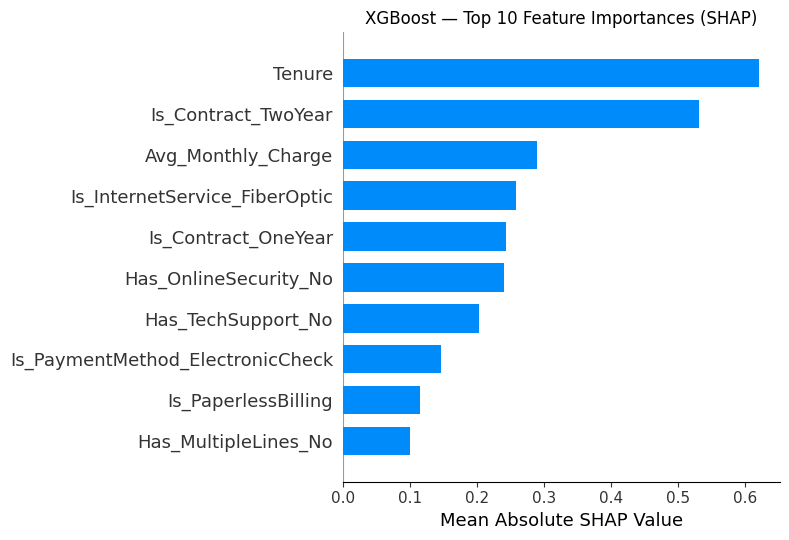

In [69]:
shap.summary_plot(shap_values, X_clf_test.astype(float), plot_type="bar", max_display=10, show=False)
plt.title("XGBoost — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

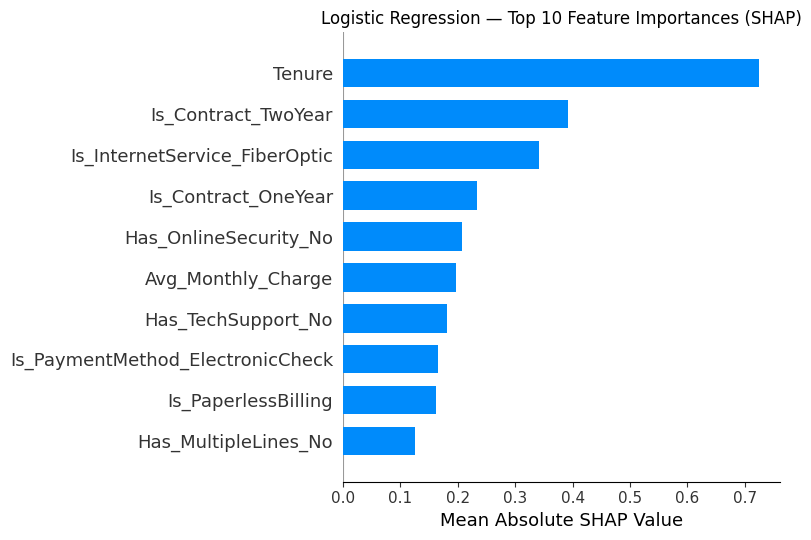

In [70]:
explainer_lr = shap.LinearExplainer(best_lr, X_clf_train.astype(float))
shap_values_lr = explainer_lr(X_clf_test.astype(float))

shap.summary_plot(shap_values_lr, X_clf_test.astype(float), plot_type="bar", max_display=10, show=False)
plt.title("Logistic Regression — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

Main takeaways:

*   Tenure — most important in both models by far
*   Is_Contract_TwoYear — second most important in both
*   Is_InternetService_FiberOptic — appears in top 3 for Logistic Regression, XGBoost ranks Avg_Monthly_Charge 3rd instead

# REGRESSION

I drop Is_Churned too, because in real life we wouldn't know if a customer has churned yet at the time we are trying to predict their monthly charge. The model should predict the charge based on their service and account features only, not on an outcome that happens after the fact.


In [71]:
# Regression features & target
X_reg = df.drop(columns=['Is_Churned', 'Avg_Monthly_Charge'])
y_reg = df['Avg_Monthly_Charge']

# Train/test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_reg_train.shape} | Test: {X_reg_test.shape}")
print(f"\nTarget stats:\n{y_reg.describe()}")

Train: (5634, 28) | Test: (1409, 28)

Target stats:
count    7043.000000
mean       64.698184
std        30.270690
min         0.000000
25%        35.650000
50%        70.300000
75%        90.170000
max       121.400000
Name: Avg_Monthly_Charge, dtype: float64


# Model 1 — XGBoost Regressor

In [72]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    random_state=RANDOM_STATE
)

In [73]:
param_grid_xgb_reg = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

In [74]:
grid_xgb_reg = GridSearchCV(
    xgb_reg,              # the model we defined
    param_grid_xgb_reg,   # the combinations to try
    cv=5,                 # 5 fold cross validation
    scoring='r2',         # optimise for R² score (how well it explains variance)
    n_jobs=-1             # use all CPU cores
)

grid_xgb_reg.fit(X_reg_train, y_reg_train)

print("Best params:", grid_xgb_reg.best_params_)
print("Best R² score (train):", round(grid_xgb_reg.best_score_, 4))

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best R² score (train): 0.9897


In [75]:
best_xgb_reg = grid_xgb_reg.best_estimator_

y_pred_xgb_reg = best_xgb_reg.predict(X_reg_test)

print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_xgb_reg):.4f}")
print(f"R²:   {r2_score(y_reg_test, y_pred_xgb_reg):.4f}")

MAE:  2.0882
R²:   0.9905


The XGBoost Regressor performed exceptionally well on unseen data. With an R² of 0.9905 the model explains 99% of the variance in monthly charges, meaning it almost perfectly understands what drives a customer's bill.
The MAE of 2.09 means that on average the model is only $2.09 off on a scale of 0 to 121, which is a very small error in business terms. Notably the R² slightly improved from training (0.9897) to test (0.9905), confirming there is no overfitting and the model generalises well to new customers.



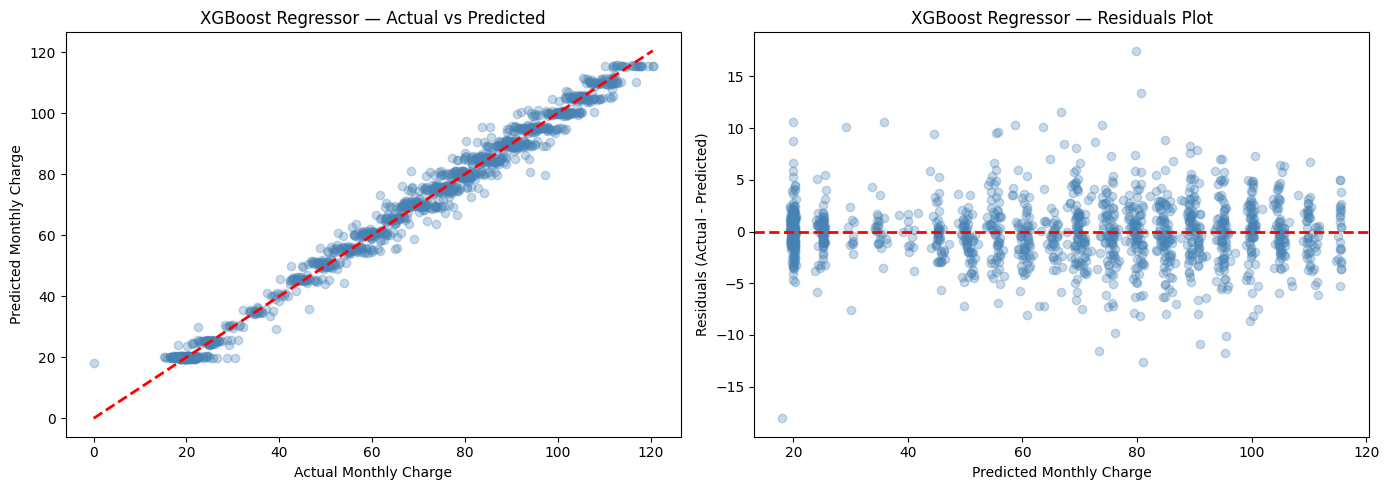

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Actual vs Predicted
axes[0].scatter(y_reg_test, y_pred_xgb_reg, alpha=0.3, color='steelblue')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()],
             'r--', linewidth=2)
axes[0].set_xlabel("Actual Monthly Charge")
axes[0].set_ylabel("Predicted Monthly Charge")
axes[0].set_title("XGBoost Regressor — Actual vs Predicted")

# Plot 2 — Residuals
residuals = y_reg_test - y_pred_xgb_reg
axes[1].scatter(y_pred_xgb_reg, residuals, alpha=0.3, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel("Predicted Monthly Charge")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("XGBoost Regressor — Residuals Plot")

plt.tight_layout()
plt.show()

The Actual vs Predicted plot shows points almost perfectly aligned along the diagonal line, confirming the model's R² of 0.99 visually. The Residuals plot shows the difference between actual and predicted values (a good model has these scattered randomly around 0 with no pattern, meaning it is not systematically over or under predicting). Ours are mostly within a -5 to +5 range, confirming this is a strong, well-behaved model with no systematic bias.

# Model 2 — Ridge Regression

In [78]:
from sklearn.linear_model import Ridge

ridge = Ridge()

In [79]:
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1, 10, 100]  # controls how much to penalise large coefficients
}

In [80]:
grid_ridge = GridSearchCV(
    ridge,             # the model we defined
    param_grid_ridge,  # the combinations to try
    cv=5,              # 5 fold cross validation
    scoring='r2',      # optimise for R² score
    n_jobs=-1          # use all CPU cores
)

grid_ridge.fit(X_reg_train, y_reg_train)

print("Best params:", grid_ridge.best_params_)
print("Best R² score (train):", round(grid_ridge.best_score_, 4))

Best params: {'alpha': 0.01}
Best R² score (train): 0.9877




*  alpha=0.01 — very little penalty, meaning the data has a strong linear relationship that doesn't need much regularisation

*   R² of 0.9877 on training — slightly lower than XGBoost's 0.9897 but still excellent




In [81]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge = best_ridge.predict(X_reg_test)

print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_ridge):.4f}")
print(f"R²:   {r2_score(y_reg_test, y_pred_ridge):.4f}")

MAE:  2.0417
R²:   0.9871




*   XGBoost wins on R² — explains slightly more variance
*   Ridge wins on MAE — actually makes smaller errors on average by 0.04



Both are good models. The fact that Ridge gets this close to XGBoost tells us the relationship between features and monthly charge is largely linear, services and plans directly add up to the bill which makes perfect sense for a telecom company.

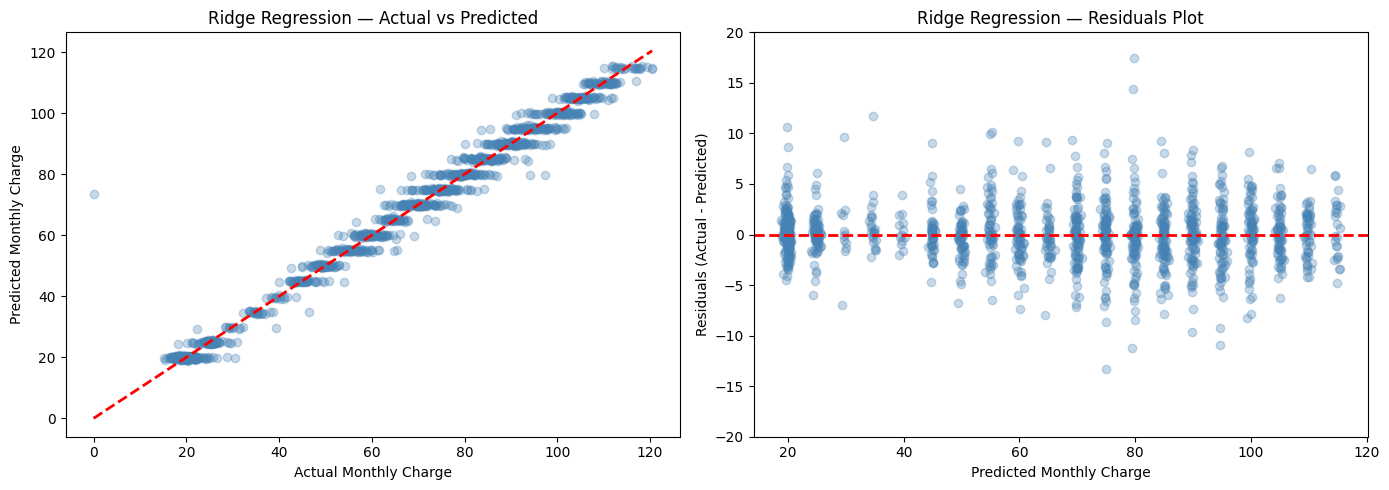

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Actual vs Predicted
axes[0].scatter(y_reg_test, y_pred_ridge, alpha=0.3, color='steelblue')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()],
             'r--', linewidth=2)
axes[0].set_xlabel("Actual Monthly Charge")
axes[0].set_ylabel("Predicted Monthly Charge")
axes[0].set_title("Ridge Regression — Actual vs Predicted")

# Plot 2 — Residuals (same scale as XGBoost)
residuals_ridge = y_reg_test - y_pred_ridge
axes[1].scatter(y_pred_ridge, residuals_ridge, alpha=0.3, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_ylim(-20, 20)  # same scale as XGBoost
axes[1].set_xlabel("Predicted Monthly Charge")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Ridge Regression — Residuals Plot")

plt.tight_layout()
plt.show()

We can see that ridge is very comparable to XGBoost, as both have residuals mostly within -5 to +5

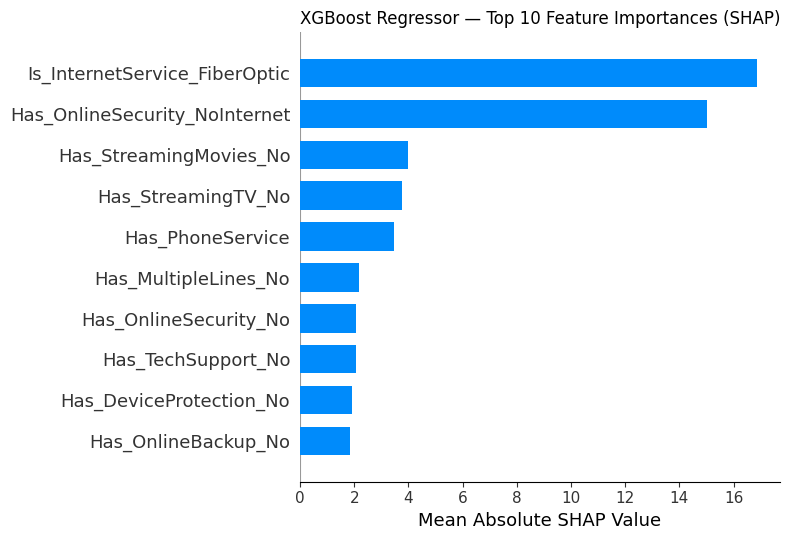

In [86]:
explainer_xgb_reg = shap.Explainer(best_xgb_reg, X_reg_train.astype(float))
shap_values_xgb_reg = explainer_xgb_reg(X_reg_test.astype(float))

shap.summary_plot(shap_values_xgb_reg, X_reg_test.astype(float), plot_type="bar", max_display=10, show=False)
plt.title("XGBoost Regressor — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

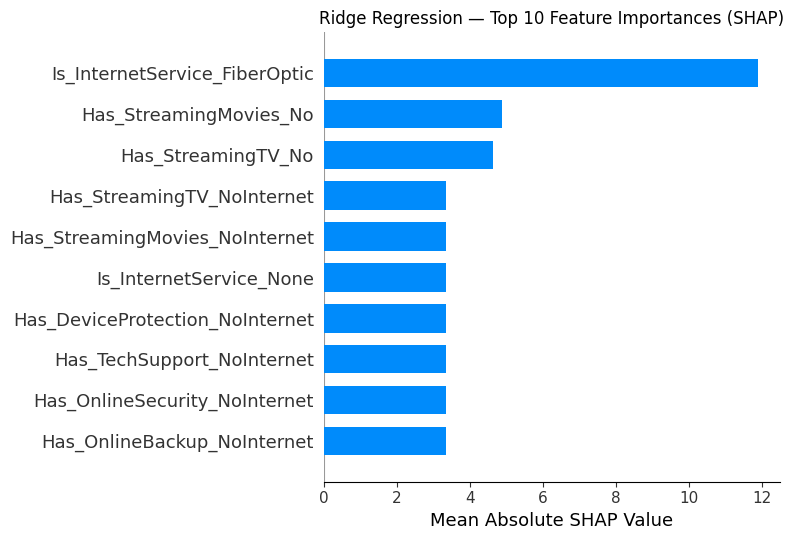

In [87]:
explainer_ridge = shap.LinearExplainer(best_ridge, X_reg_train.astype(float))
shap_values_ridge = explainer_ridge(X_reg_test.astype(float))

shap.summary_plot(shap_values_ridge, X_reg_test.astype(float), plot_type="bar", max_display=10, show=False)
plt.title("Ridge Regression — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

Both models agree that Is_InternetService_FiberOptic is by far the most important feature driving monthly charges. XGBoost highlights Has_OnlineSecurity_NoInternet as a strong second driver, meaning customers without internet pay significantly less. Ridge spreads importance more evenly across NoInternet features, confirming the same story from a different angle: not having internet service is the biggest factor pulling monthly charges down. Overall both models confirm that monthly charges are primarily determined by the type of internet service a customer has, and which add-ons they subscribe to on top of it.

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [92]:
!git config --global user.email "milenamirumyan14@gmail.com"
!git config --global user.name "milena"

In [93]:
!git clone https://github.com/kitlapp/Telco_ML.git
%cd Telco_ML
!git checkout -b milena

Cloning into 'Telco_ML'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 81 (delta 23), reused 14 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 9.43 MiB | 9.13 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/Telco_ML
Switched to a new branch 'milena'


In [94]:
import shutil
shutil.copy('/content/drive/MyDrive/ML_proj.ipynb', '/content/Telco_ML/milena_ml.ipynb')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ML_proj.ipynb'

In [95]:
!find /content/drive/MyDrive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/ML_proj.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of ML_proj.ipynb
/content/drive/MyDrive/Colab Notebooks/KNN_PCA_Solutions.ipynb
/content/drive/MyDrive/Colab Notebooks/KNN_PCA.ipynb
/content/drive/MyDrive/Colab Notebooks/KNN_Hyperparameter_Tuning_Solutions.ipynb
/content/drive/MyDrive/Colab Notebooks/KNN_Hyperparameter_Tuning.ipynb
/content/drive/MyDrive/Colab Notebooks/InClass#1.ipynb
/content/drive/MyDrive/Colab Notebooks/DT_RFs_Solutions.ipynb
/content/drive/MyDrive/Colab Notebooks/DT_RFs.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Clustering.ipynb
/content/drive/MyDrive/Colab Notebooks/Clustering_Solutions.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/DV_project_preproc.ipynb
